# How to generate `Alpha` channel with transparency
- `Alpha` channel: The `display ratio of this image` relative to the background ₩

- 0 : none of this image $\rightarrow$ only background $\rightarrow$ transparent

- 255: only this image $\rightarrow$ no background $\rightarrow$ non-transparent


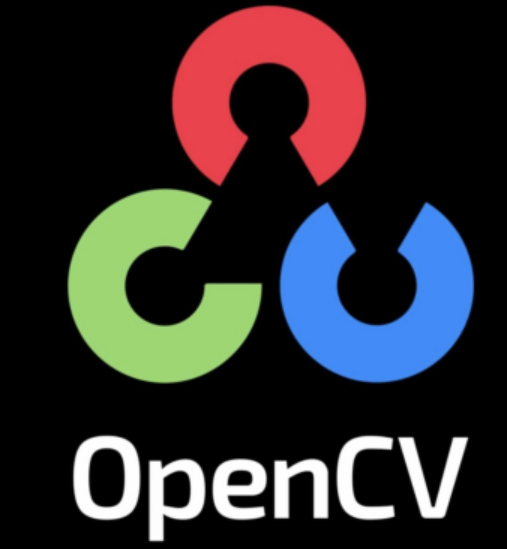

(681, 613, 4) float32


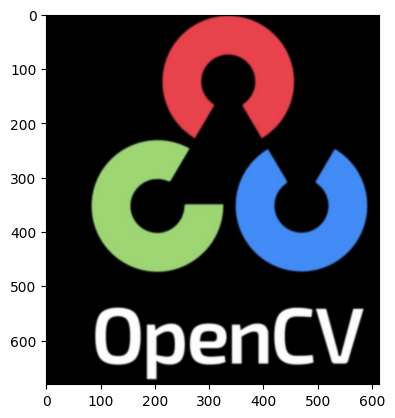

In [11]:
import numpy as np
import matplotlib.pyplot as plt

src = plt.imread('images/Opencv-logo.jpg')

print(src.shape, src.dtype)
plt.imshow(src)
plt.show()

### Create a new image with alpha channe where black will be masked out (transparent)

#### 1. Generate a matrix to select corresponding pixels including the desired color (Black)

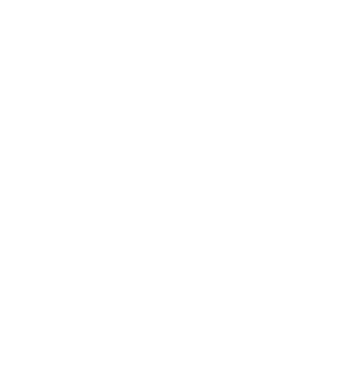

In [9]:
thr = 50

rgb = src[:, :, :3].astype(np.uint8)
locs = (rgb[:, :, 0] < thr) & (rgb[:, :, 1] < thr) & (rgb[:, :, 2] < thr)

src_tmp = rgb.copy()
src_tmp[locs] = [255, 255, 255]

plt.imshow(src_tmp)
plt.axis('off')
plt.show()


#### 2. Generate `alpha channel`
- Black pixels should be `transparent`
- The corresponding pixels in the alpha channel should be `zero`.

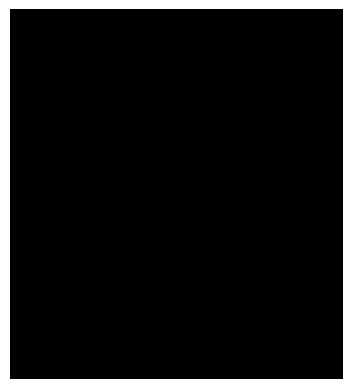

In [3]:
alpha = np.where(locs, 0, 255).astype(np.uint8)

plt.imshow(alpha, cmap='gray')
plt.axis('off')
plt.show()


#### 3. Concatenate the alpha channel to the original image in the axis=3
- `New image will have four channels`


- np.vstack: Stacks along Axis=0 (`Rows`)
- np.hstack: Stacks along Axis=1 (`Columns`)
- np.dstack: Stacks along Axis=2 (`Depth`)

(681, 613, 4) float32


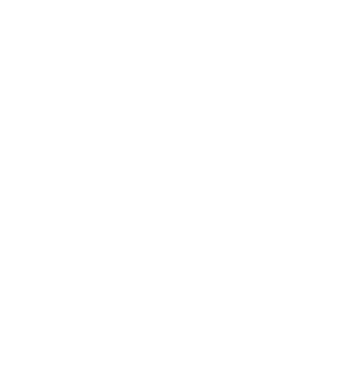

In [4]:
rgba = np.dstack((rgb, alpha))

print(rgba.shape, rgba.dtype)
plt.imshow(rgba)
plt.axis('off')
plt.show()
